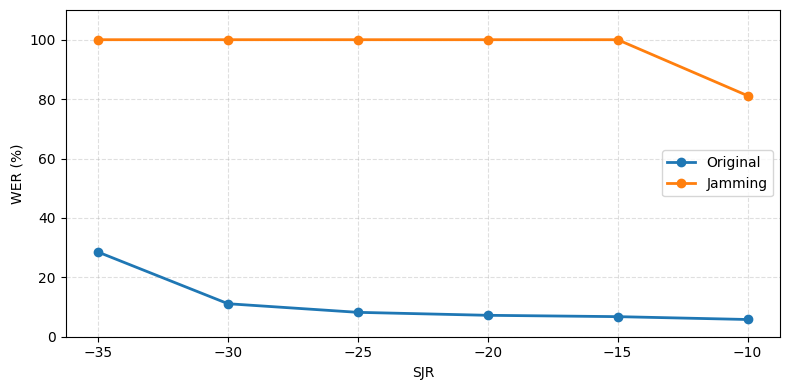

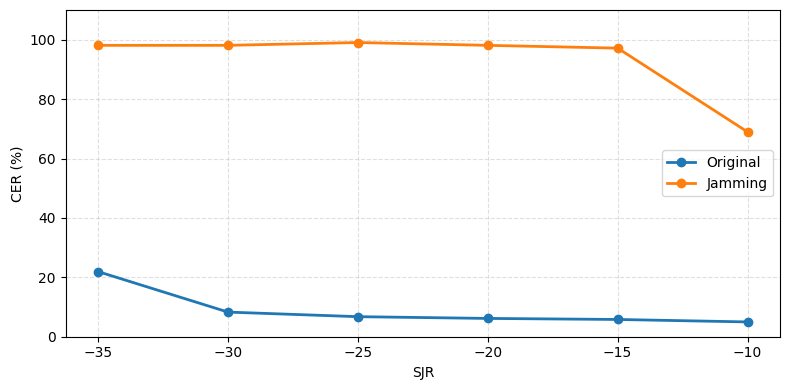

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 공통 X축: SJR (dB) =====
sjr = np.array([-35, -30, -25, -20, -15, -10], dtype=float)

# ======= 데이터 =======
wer_series = {
    "Original": [28.5, 11.11, 8.21, 7.21, 6.76, 5.80],
    "Jamming":  [100, 100, 100, 100, 100, 81.16],
}
cer_series = {
    "Original": [21.92, 8.29, 6.75, 6.16, 5.81, 4.98],
    "Jamming":  [98.10, 98.10, 99.05, 98.10, 97.16, 68.96],
}

def _check_len(series_by_key, name):
    for k, v in series_by_key.items():
        if len(v) != len(sjr):
            raise ValueError(f"[{name}] {k} 길이({len(v)})가 SJR 길이({len(sjr)})와 다름.")

def _as_percent_if_ratio(series_by_key):
    arr = np.concatenate([np.asarray(v, dtype=float) for v in series_by_key.values()])
    is_ratio = np.nanmax(arr) <= 1.0
    if is_ratio:
        return {k: (np.asarray(v, dtype=float) * 100.0) for k, v in series_by_key.items()}, True
    return {k: np.asarray(v, dtype=float) for k, v in series_by_key.items()}, False

def plot_two_lines(series_by_key, y_label_percent):
    plt.figure(figsize=(8, 4))  # 각각 별도 Figure (subplot X)
    for key in ["Original", "Jamming"]:
        if key in series_by_key:
            y = np.asarray(series_by_key[key], dtype=float)
            plt.plot(sjr, y, marker="o", linewidth=2, label=key)
    plt.ylim(0, 110)
    plt.xlabel("SJR")
    plt.ylabel(f"{y_label_percent} (%)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="center right")  # 두 그래프 모두 동일 위치
    plt.tight_layout()
    plt.show()

# --- WER ---
_check_len(wer_series, "WER")
wer_plot, _ = _as_percent_if_ratio(wer_series)
plot_two_lines(wer_plot, y_label_percent="WER")

# --- CER ---
_check_len(cer_series, "CER")
cer_plot, _ = _as_percent_if_ratio(cer_series)
plot_two_lines(cer_plot, y_label_percent="CER")


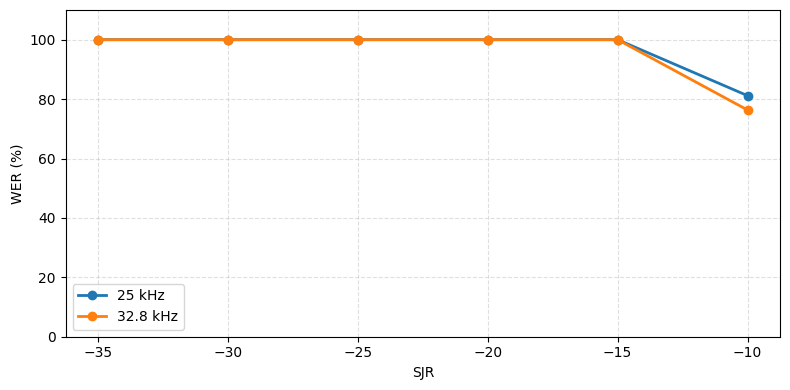

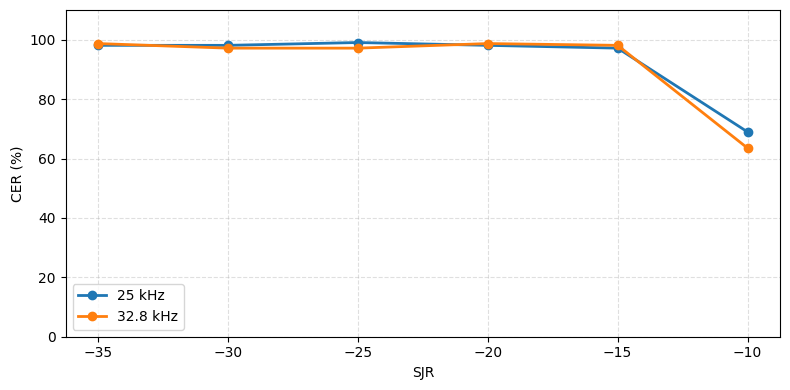

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import re

# ===== 공통 X축: SJR (dB) =====
sjr = np.array([-35, -30, -25, -20, -15, -10], dtype=float)

# ======= 데이터: 주파수별 (25 kHz, 32.8 kHz) — Jamming만 비교 =======
wer_series = {
    "25 kHz":   [100, 100, 100, 100, 100, 81.16],
    "32.8 kHz": [100, 100, 100, 100, 100, 76.33],
}
cer_series = {
    "25 kHz":   [98.10, 98.10, 99.05, 98.10, 97.16, 68.96],
    "32.8 kHz": [98.70, 97.16, 97.16, 98.70, 98.10, 63.51],
}

# ======= Helper (거리 그래프 스타일과 동일) =======
def _num_from_key(k: str) -> float:
    m = re.search(r"[-+]?\d*\.?\d+", k)  # '25', '32.8' 추출
    return float(m.group()) if m else float('inf')

def _check_lengths(series_by_key, name):
    for k, v in series_by_key.items():
        if len(v) != len(sjr):
            raise ValueError(f"[{name}] {k}의 길이({len(v)})가 SJR 길이({len(sjr)})와 다릅니다.")

def _is_ratio(series_by_key):
    arr = np.concatenate([np.asarray(v, dtype=float) for v in series_by_key.values()])
    return np.nanmax(arr) <= 1.0

def plot_lines(series_by_key, y_label):
    plt.figure(figsize=(8, 4))
    for key in sorted(series_by_key.keys(), key=_num_from_key):  # 숫자 기반 정렬
        y = np.asarray(series_by_key[key], dtype=float)
        plt.plot(sjr, y, marker="o", linewidth=2, label=key)
    plt.ylim(0, 110)
    plt.xlabel("SJR")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left")  # ✅ 거리 그래프와 동일 위치
    plt.tight_layout()
    plt.show()

# ======= WER =======
_check_lengths(wer_series, "WER")
# 필요 시 비율→백분율 변환(여기선 이미 %라 그대로 사용)
wer_use_percent = _is_ratio(wer_series)
wer_plot = {k: (np.asarray(v, dtype=float) * 100.0 if wer_use_percent else np.asarray(v, dtype=float))
            for k, v in wer_series.items()}
plot_lines(wer_plot, y_label="WER (%)")

# ======= CER =======
_check_lengths(cer_series, "CER")
cer_use_percent = _is_ratio(cer_series)
cer_plot = {k: (np.asarray(v, dtype=float) * 100.0 if cer_use_percent else np.asarray(v, dtype=float))
            for k, v in cer_series.items()}
plot_lines(cer_plot, y_label="CER (%)")


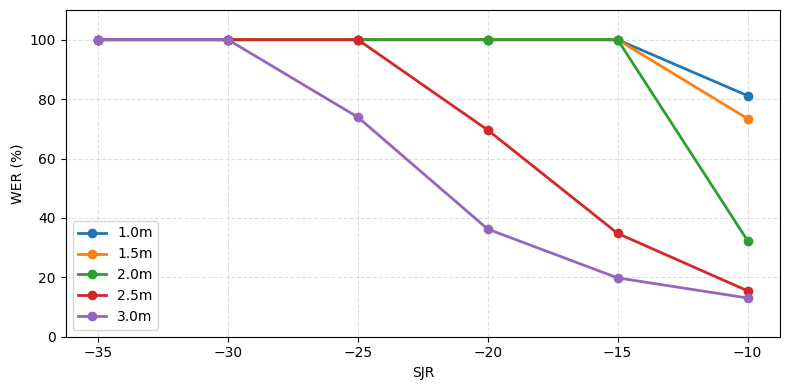

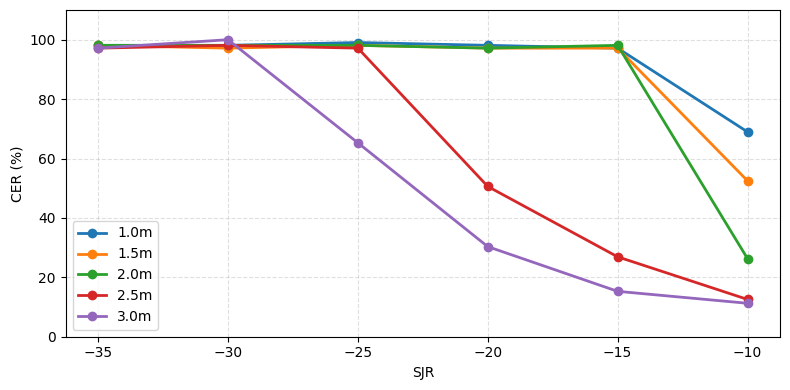

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import re

# ===== 공통 X축: SJR (dB) =====
sjr = np.array([-35, -30, -25, -20, -15, -10], dtype=float)

# ===== 거리별 WER (%) =====
wer_by_distance = {
    "1.0m":  [100, 100, 100, 100, 100, 81.16],
    "1.5m":  [100, 100, 100, 100, 100, 73.43],
    "2.0m":  [100, 100, 100, 100, 100, 32.37],
    "2.5m":  [100, 100, 100, 69.57, 34.78, 15.46],
    "3.0m":  [100, 100, 73.91, 36.23, 19.81, 13.04]
}

# ===== 거리별 CER (%) =====
cer_by_distance = {
    "1.0m":  [98.10, 98.10, 99.05, 98.10, 97.16, 68.96],
    "1.5m":  [98.10, 97.16, 98.10, 97.16, 97.16, 52.49],
    "2.0m":  [98.10, 98.10, 98.10, 97.16, 98.10, 26.30],
    "2.5m":  [97.16, 98.10, 97.16, 50.59, 26.90, 12.56],
    "3.0m":  [97.16, 100, 65.28, 30.33, 15.28, 11.26]
}

def _num_from_key(k: str) -> float:
    m = re.search(r"[-+]?\d*\.?\d+", k)
    return float(m.group()) if m else float('inf')

def _check_lengths(series_by_key, name):
    for k, v in series_by_key.items():
        if len(v) != len(sjr):
            raise ValueError(f"[{name}] {k}의 길이({len(v)})가 SJR 길이({len(sjr)})와 다릅니다.")

def _is_ratio(series_by_key):
    arr = np.concatenate([np.asarray(v, dtype=float) for v in series_by_key.values()])
    return np.nanmax(arr) <= 1.0

def plot_lines(series_by_key, y_label):
    plt.figure(figsize=(8, 4))
    for key in sorted(series_by_key.keys(), key=_num_from_key):
        y = np.asarray(series_by_key[key], dtype=float)
        plt.plot(sjr, y, marker="o", linewidth=2, label=key)
    plt.ylim(0, 110)
    plt.xlabel("SJR")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left")  # ✅ 왼쪽 아래로 이동
    plt.tight_layout()
    plt.show()

# ======= WER =======
_check_lengths(wer_by_distance, "WER")
plot_lines(wer_by_distance, y_label="WER (%)")

# ======= CER =======
_check_lengths(cer_by_distance, "CER")
cer_use_percent = _is_ratio(cer_by_distance)
cer_plot = {k: (np.asarray(v, dtype=float) * 100.0 if cer_use_percent else np.asarray(v, dtype=float))
            for k, v in cer_by_distance.items()}
plot_lines(cer_plot, y_label="CER (%)")


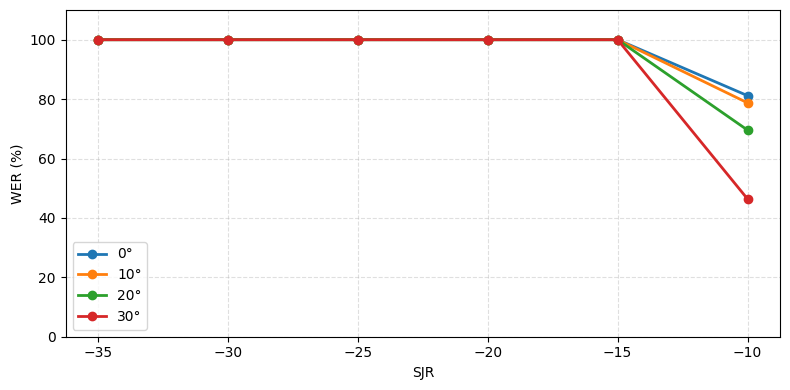

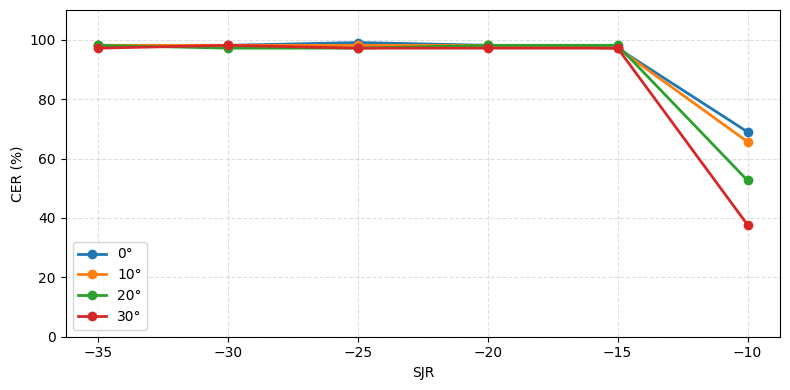

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 공통 X축: SJR (dB) =====
sjr = np.array([-35, -30, -25, -20, -15, -10], dtype=float)

# ===== 각도별 WER (%) =====
wer_by_angle = {
    "0":   [100, 100, 100, 100, 100, 81.16],
    "10":  [100, 100, 100, 100, 100, 78.74],
    "20":  [100, 100, 100, 100, 100, 69.57],
    "30":  [100, 100, 100, 100, 100, 46.38],
}

# ===== 각도별 CER (%) =====
cer_by_angle = {
    "0":   [98.10, 98.10, 99.05, 98.10, 97.16, 68.96],
    "10":  [98.10, 98.10, 98.10, 98.10, 97.16, 65.64],
    "20":  [98.10, 97.16, 97.16, 98.10, 98.10, 52.61],
    "30":  [97.16, 98.10, 97.16, 97.16, 97.16, 37.68],
}

def _check_lengths(series_by_key, name):
    for k, v in series_by_key.items():
        if len(v) != len(sjr):
            raise ValueError(f"[{name}] {k}의 길이({len(v)})가 SJR 길이({len(sjr)})와 다릅니다.")

def _is_ratio(series_by_key):
    arr = np.concatenate([np.asarray(v, dtype=float) for v in series_by_key.values()])
    return np.nanmax(arr) <= 1.0

def plot_lines(series_by_key, y_label):
    plt.figure(figsize=(8, 4))
    for key in sorted(series_by_key.keys(), key=lambda x: float(x)):
        y = np.asarray(series_by_key[key], dtype=float)
        plt.plot(sjr, y, marker="o", linewidth=2, label=f"{key}°")
    plt.ylim(0, 110)
    plt.xlabel("SJR")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left")  # ✅ 왼쪽 아래로 이동 & "Angle" 제목 제거
    plt.tight_layout()
    plt.show()

# ======= WER =======
_check_lengths(wer_by_angle, "WER")
plot_lines(wer_by_angle, y_label="WER (%)")

# ======= CER =======
_check_lengths(cer_by_angle, "CER")
cer_use_percent = _is_ratio(cer_by_angle)
cer_plot = {k: (np.asarray(v, dtype=float) * 100.0 if cer_use_percent else np.asarray(v, dtype=float))
            for k, v in cer_by_angle.items()}
plot_lines(cer_plot, y_label="CER (%)")


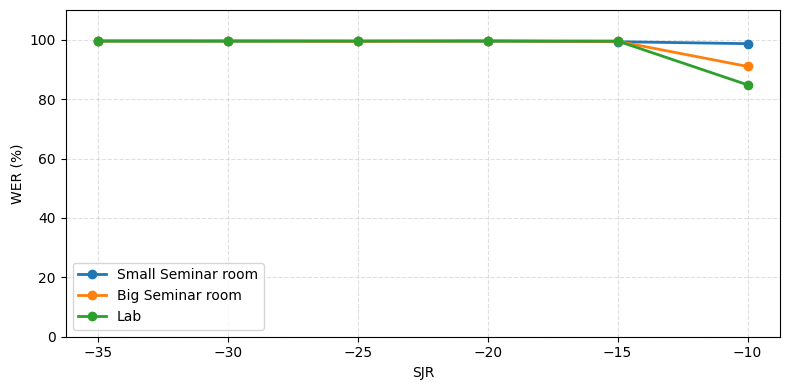

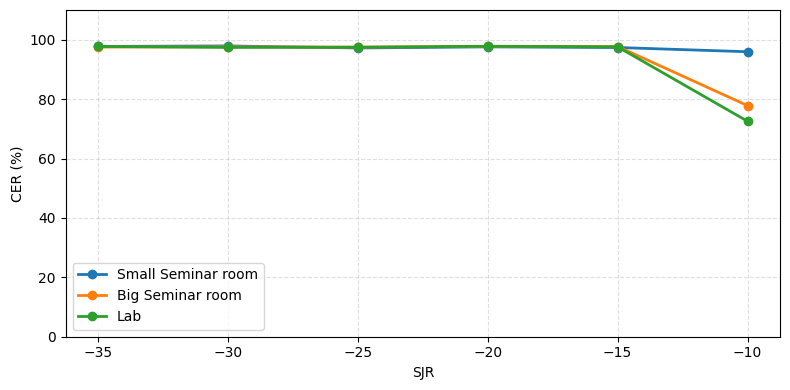

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 공통 X축: SJR (dB) =====
sjr = np.array([-35, -30, -25, -20, -15, -10], dtype=float)

# ===== 공간별 WER/CER =====
wer_by_space = {
    "Small Seminar room": [99.55, 99.55, 99.51, 99.55, 99.32, 98.67],
    "Big Seminar room":   [99.55, 99.55, 99.47, 99.55, 99.45, 91.00],
    "Lab":                [99.55, 99.53, 99.55, 99.55, 99.55, 84.80],
}

cer_by_space = {
    "Small Seminar room": [97.73, 97.90, 97.22, 97.59, 97.37, 95.95],
    "Big Seminar room":   [97.52, 97.59, 97.51, 97.77, 97.71, 77.82],
    "Lab":                [97.73, 97.41, 97.46, 97.80, 97.59, 72.55],
}

# ===== 유틸 =====
ORDER = ["Small Seminar room", "Big Seminar room", "Lab"]

def _check_lengths(series_by_key, name):
    for k, v in series_by_key.items():
        if len(v) != len(sjr):
            raise ValueError(f"[{name}] {k}의 길이({len(v)})가 SJR 길이({len(sjr)})와 다릅니다.")

def _is_ratio(series_by_key):
    arr = np.concatenate([np.asarray(v, dtype=float) for v in series_by_key.values()])
    return np.nanmax(arr) <= 1.0

def plot_lines(series_by_key, y_label):
    plt.figure(figsize=(8, 4))
    for key in [k for k in ORDER if k in series_by_key]:
        y = np.asarray(series_by_key[key], dtype=float)
        plt.plot(sjr, y, marker="o", linewidth=2, label=key)
    plt.ylim(0, 110)
    plt.xlabel("SJR")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left")  # ✅ 범례 왼쪽 아래
    plt.tight_layout()
    plt.show()

# ======= WER =======
_check_lengths(wer_by_space, "WER")
plot_lines(wer_by_space, y_label="WER (%)")

# ======= CER =======
_check_lengths(cer_by_space, "CER")
cer_use_percent = _is_ratio(cer_by_space)
cer_plot = {k: (np.asarray(v, dtype=float) * 100.0 if cer_use_percent else np.asarray(v, dtype=float))
            for k, v in cer_by_space.items()}
plot_lines(cer_plot, y_label="CER (%)")


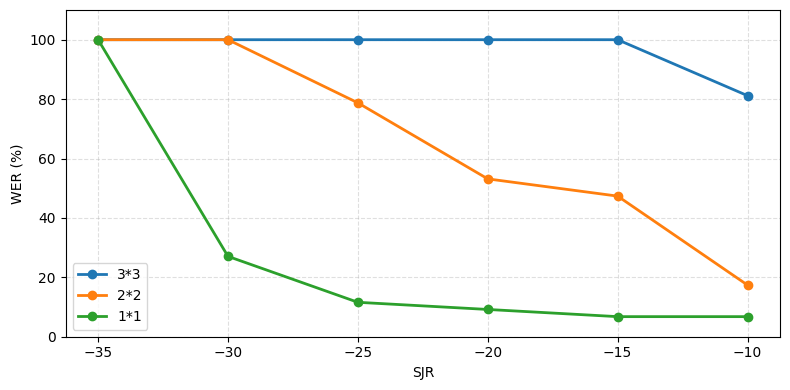

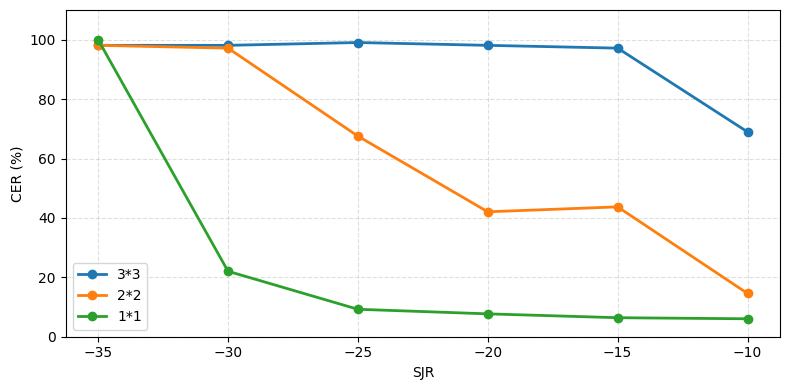

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 공통 X축: SJR (dB) =====
sjr = np.array([-35, -30, -25, -20, -15, -10], dtype=float)

# ===== Grid별 WER/CER (퍼센트 값) =====
wer_by_number = {
    "3*3": [100, 100, 100, 100, 100, 81.16],
    "2*2": [100, 100, 78.74, 53.14, 47.34, 17.39],
    "1*1": [100, 27.05, 11.59,  9.18,  6.76,  6.76],
}

cer_by_number = {
    "3*3": [98.10, 98.10, 99.05, 98.10, 97.16, 68.96],
    "2*2": [98.10, 97.16, 67.54, 42.06, 43.72, 14.57],
    "1*1": [100.0, 22.04,  9.24,  7.70,  6.40,  6.04],
}

ORDER = ["3*3", "2*2", "1*1"]

def _check_lengths(series_by_key, name):
    for k, v in series_by_key.items():
        if len(v) != len(sjr):
            raise ValueError(f"[{name}] {k}의 길이({len(v)})가 SJR 길이({len(sjr)})와 다릅니다.")

def plot_lines(series_by_key, y_label):
    plt.figure(figsize=(8, 4))  # 각 차트는 별도 Figure
    for key in [k for k in ORDER if k in series_by_key]:
        y = np.asarray(series_by_key[key], dtype=float)
        plt.plot(sjr, y, marker="o", linewidth=2, label=key)
    plt.ylim(0, 110)
    plt.xlabel("SJR")
    plt.ylabel(y_label)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="lower left")  # ✅ 범례 왼쪽 아래
    plt.tight_layout()
    plt.show()

# ======= 길이 검증 & 플롯 =======
_check_lengths(wer_by_number, "WER")
plot_lines(wer_by_number, y_label="WER (%)")

_check_lengths(cer_by_number, "CER")
plot_lines(cer_by_number, y_label="CER (%)")
